# Rural Microfinance: EDA & Target Engineering

Public microfinance datasets almost never contain a `Default` column.
We will **mathematically engineer a realistic Risk/Default `TARGET`** based on
true financial stress indicators, after carefully cleaning the messy free-text columns.

### Full Data Pipeline:
1. **Load** `RuralCreditData.csv`
2. **Normalize Dirty Categorical Columns** (social_class, business, home type)
3. **Handle Missing Values**
4. **Synthetic Target Engineering** (Mathematically assign Risk logic)
5. **Encode** (Label + One-Hot Encoding — now safe and compact)
6. **Save** to `data/processed/rural_microfinance/`

In [9]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
import warnings
warnings.filterwarnings('ignore')

plt.style.use('fivethirtyeight')

RAW_PATH = '../../data/raw/rural_microfinance/'
df = pd.read_csv(RAW_PATH + 'RuralCreditData.csv')
df.columns = df.columns.str.strip()

print(f"Base Rural Data shape: {df.shape}")
print("\nColumns:", df.columns.tolist())
df.head()

Base Rural Data shape: (40000, 21)

Columns: ['Id', 'city', 'age', 'sex', 'social_class', 'primary_business', 'secondary_business', 'annual_income', 'monthly_expenses', 'old_dependents', 'young_dependents', 'home_ownership', 'type_of_house', 'occupants_count', 'house_area', 'sanitary_availability', 'water_availabity', 'loan_purpose', 'loan_tenure', 'loan_installments', 'loan_amount']


,Id,city,age,sex,social_class,primary_business,secondary_business,annual_income,monthly_expenses,old_dependents,...,home_ownership,type_of_house,occupants_count,house_area,sanitary_availability,water_availabity,loan_purpose,loan_tenure,loan_installments,loan_amount
0,1,Dhanbad,22,F,Mochi,Tailoring,Others,36000.0,5000.0,0,...,1.0,R,4,70.0,1.0,0.5,Apparels,12,12,5000.0
1,2,Manjapra,21,F,OBC,Tailoring,none,94000.0,3600.0,1,...,1.0,T1,4,80.0,1.0,0.5,Apparels,12,50,7500.0
2,3,Dhanbad,24,M,Nai,Beauty salon,Others,48000.0,4000.0,0,...,1.0,T1,4,50.0,1.0,0.5,Beauty Salon,12,12,5000.0
3,4,NaN,26,F,OBC,Tailoring,none,7000.0,5000.0,0,...,1.0,T1,5,50.0,1.0,0.5,Apparels,12,50,7500.0
4,5,Nuapada,23,F,OBC,General store,Agriculture,36000.0,3500.0,0,...,1.0,T1,1,112.0,1.0,0.5,Retail Store,12,12,5000.0


## Step 1: Normalize Dirty Categorical Columns

The `social_class` column contains 500+ unique free-text caste entries
(e.g., "General", "GEN", "GENERAL", "Gen", "Genaral" are all the same).
We normalize all of them into 5 standard Indian reservation categories.

Similarly, `primary_business` & `secondary_business` have hundreds of unique
occupation strings. We group them into broad economic sectors so One-Hot
Encoding stays compact (5-8 columns instead of 500+).

In [10]:
# ---- 1. NORMALIZE social_class ----
def normalize_social_class(val):
    if pd.isnull(val):
        return 'Other'
    v = str(val).strip().upper()
    # ST patterns
    if any(x in v for x in ['S.T', 'ST ', ' ST', 'TRIBE', 'TRIBAL', 'ADIWASH', 'ADIVASI',
                              'GOND', 'BAIGA', 'ORAON', 'BHIL', 'BHEEL', 'SOLIGA',
                              'JENU KURUBA', 'BEDA JANGAMA']):
        return 'ST'
    # SC patterns
    if any(x in v for x in ['S.C', 'SC ', ' SC', 'SCHEDULED CASTE', 'SCHEDULE CASTE',
                              'HARIJAN', 'CHAMAR', 'CHAMBAR', 'CHAMBHAR', 'DHOBI', 'BHANGI',
                              'MAHAR', 'MATANG', 'MANG', 'MOCHI', 'VALMIKI', 'YADAV',
                              'ADI KARNATAKA']):
        return 'SC'
    # OBC patterns
    if any(x in v for x in ['OBC', 'O.B.C', 'O B C', 'BACKWARD', 'MBC', 'SEBC', 'SBC',
                              'KURMEE', 'KURMI', 'KUMBHAR', 'KUMHAR', 'TELI', 'LOHAR',
                              'NAYAK', 'GOND', 'KOLI', 'KUNABI', 'DHANGAR', 'MALI',
                              'GOWDA', 'LINGAYAT', 'OKKALIGA', 'EZHAVA', 'NAIR']):
        return 'OBC'
    # Minority patterns
    if any(x in v for x in ['MUSLIM', 'MUSLI', 'ISLAM', 'CHRISTIAN', 'CHRISTAIN',
                              'SIKHI', 'MINORITY', 'MINORI', 'JAIN', 'BUDDHIST',
                              'BAUDH', 'BOUDH', 'KHAN']):
        return 'Minority'
    # General / Open patterns
    if any(x in v for x in ['GENERAL', 'GEN', 'OPEN', 'UNRESERVED', 'UR', 'GC',
                              'BRAHMAN', 'BRAMAN', 'RAJPUT', 'THAKUR', 'PATEL',
                              'MARATHA', 'KSHATRIYA', 'KAYASTHA']):
        return 'General'
    return 'Other'

df['social_class'] = df['social_class'].apply(normalize_social_class)
print("social_class unique values after normalization:")
print(df['social_class'].value_counts())


# ---- 2. NORMALIZE primary_business & secondary_business into SECTORS ----
SECTOR_MAP = {
    # Agriculture & Livestock
    'agri': 'Agriculture', 'farm': 'Agriculture', 'crop': 'Agriculture',
    'cattle': 'Agriculture', 'cow': 'Agriculture', 'goat': 'Agriculture',
    'poultry': 'Agriculture', 'fish': 'Agriculture', 'milk': 'Agriculture',
    'dairy': 'Agriculture', 'buffalo': 'Agriculture', 'duck': 'Agriculture',
    'banana': 'Agriculture', 'ginger': 'Agriculture', 'flower': 'Agriculture',
    # Food & Catering
    'food': 'Food_Trade', 'hotel': 'Food_Trade', 'tiffin': 'Food_Trade',
    'mess': 'Food_Trade', 'bakery': 'Food_Trade', 'canteen': 'Food_Trade',
    'cafe': 'Food_Trade', 'juice': 'Food_Trade', 'sweets': 'Food_Trade',
    'cook': 'Food_Trade', 'restaurant': 'Food_Trade', 'biryani': 'Food_Trade',
    # Retail & Trading
    'shop': 'Retail_Trade', 'store': 'Retail_Trade', 'sell': 'Retail_Trade',
    'kirana': 'Retail_Trade', 'vendor': 'Retail_Trade', 'trade': 'Retail_Trade',
    'cloth': 'Retail_Trade', 'market': 'Retail_Trade', 'wholesale': 'Retail_Trade',
    'retail': 'Retail_Trade', 'daily needs': 'Retail_Trade',
    # Tailoring & Textile
    'tailor': 'Tailoring_Textile', 'sew': 'Tailoring_Textile',
    'weav': 'Tailoring_Textile', 'embroider': 'Tailoring_Textile',
    'knit': 'Tailoring_Textile', 'garment': 'Tailoring_Textile',
    # Artisan & Craft
    'craft': 'Artisan_Craft', 'potter': 'Artisan_Craft', 'basket': 'Artisan_Craft',
    'coir': 'Artisan_Craft', 'mat': 'Artisan_Craft', 'broom': 'Artisan_Craft',
    'bamboo': 'Artisan_Craft', 'wood': 'Artisan_Craft', 'leather': 'Artisan_Craft',
    'jewel': 'Artisan_Craft', 'artisan': 'Artisan_Craft',
    # Services & Labour
    'salon': 'Services', 'parlour': 'Services', 'barber': 'Services',
    'driver': 'Services', 'auto': 'Services', 'transport': 'Services',
    'repair': 'Services', 'mechanic': 'Services', 'electric': 'Services',
    'plumber': 'Services', 'labour': 'Services', 'labor': 'Services',
    'laundry': 'Services', 'iron': 'Services',
}

def normalize_business(val):
    if pd.isnull(val) or str(val).strip().lower() in ('none', 'others', 'other', 'nil', ''):
        return 'Other'
    v = str(val).strip().lower()
    for keyword, sector in SECTOR_MAP.items():
        if keyword in v:
            return sector
    return 'Other'

df['primary_business']   = df['primary_business'].apply(normalize_business)
df['secondary_business'] = df['secondary_business'].apply(normalize_business)

print("\nprimary_business unique sectors:")
print(df['primary_business'].value_counts())
print("\nsecondary_business unique sectors:")
print(df['secondary_business'].value_counts())


# ---- 3. NORMALIZE type_of_house ----
def normalize_house_type(val):
    if pd.isnull(val):
        return 'Other'
    v = str(val).strip().upper()
    if v in ('T1', 'PUCCA', 'CONCRETE', 'RCC', 'BRICK'):
        return 'Pucca'
    if v in ('T2', 'SEMI', 'SEMI-PUCCA', 'SEMI PUCCA'):
        return 'Semi_Pucca'
    if v in ('R', 'KACHA', 'KUTCHA', 'THATCHED', 'MUD', 'HUT'):
        return 'Kutcha'
    return 'Other'

df['type_of_house'] = df['type_of_house'].apply(normalize_house_type)
print("\ntype_of_house unique values:")
print(df['type_of_house'].value_counts())

# ---- 4. NORMALIZE home_ownership ----
# home_ownership is already numeric (1 = owned); we check its unique values
print("\nhome_ownership unique values:")
print(df['home_ownership'].value_counts())

social_class unique values after normalization:
social_class
Other       16852
OBC         12011
General      5163
Minority     3388
SC           2185
ST            401
Name: count, dtype: int64

primary_business unique sectors:
primary_business
Other                14794
Agriculture           9239
Tailoring_Textile     6450
Retail_Trade          6059
Artisan_Craft         1685
Food_Trade            1149
Services               624
Name: count, dtype: int64

secondary_business unique sectors:
secondary_business
Other          35350
Services        2545
Agriculture     2105
Name: count, dtype: int64

type_of_house unique values:
type_of_house
Semi_Pucca    17715
Pucca         15092
Kutcha         6499
Other           694
Name: count, dtype: int64

home_ownership unique values:
home_ownership
1.0    38531
0.0     1090
Name: count, dtype: int64


## Step 2: Handle Missing Values

In [11]:
# Fill numeric columns with median
num_cols = ['annual_income', 'monthly_expenses', 'loan_amount',
            'loan_tenure', 'loan_installments', 'young_dependents', 'old_dependents',
            'occupants_count', 'house_area']
for col in num_cols:
    if col in df.columns:
        df[col] = df[col].fillna(df[col].median())

# Home ownership: if missing, assume "Rented" (more conservative/risky assumption)
if 'home_ownership' in df.columns:
    df['home_ownership'] = df['home_ownership'].fillna(0)

# Social class, business, loan_purpose: already handled by normalization above
if 'loan_purpose' in df.columns:
    df['loan_purpose'] = df['loan_purpose'].fillna('Other')

print("Remaining missing values:")
print(df.isnull().sum()[df.isnull().sum() > 0])
print("Missing values resolved." if df.isnull().sum().sum() == 0 else "")

Remaining missing values:
city                     1864
sanitary_availability     208
water_availabity         5253
dtype: int64



## Step 3: Synthetic Target Engineering (Risk Assessment)

We build a `TARGET` column (1 = Default, 0 = Repaid) using real-world
financial stress logic. The formula includes:
- Debt-to-Disposable-Income ratio (strongest signal)
- Number of dependents
- House ownership / stability
- Business sector (Agriculture is more volatile than salaried)
- Random noise (to simulate real-world unpredictability)

Synthetic Target Generated!
Default Rate: 15.00%
Target distribution: {0: 34000, 1: 6000}


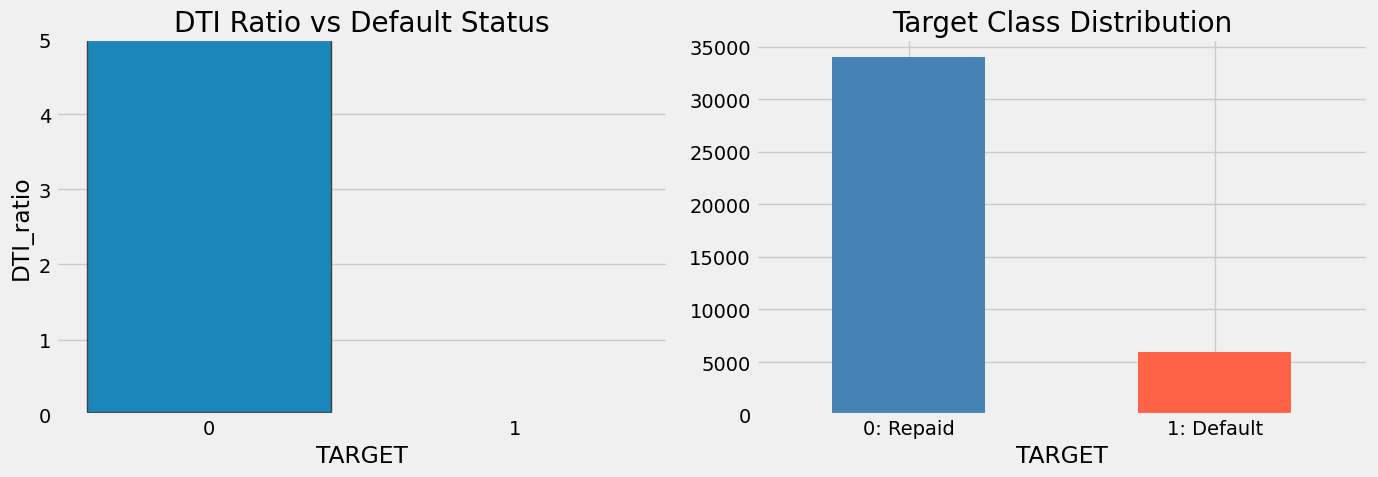

In [12]:
np.random.seed(42)

# 1. Net Disposable Income (monthly)
df['net_disposable_income'] = (df['annual_income'] / 12) - df['monthly_expenses']
df['net_disposable_income'] = df['net_disposable_income'].clip(lower=1)

# 2. Debt-to-Income Ratio (DTI)
df['DTI_ratio'] = df['loan_installments'] / df['net_disposable_income']

# 3. Total Dependents
df['total_dependents'] = df['young_dependents'] + df['old_dependents']

# 4. Agriculture sector flag (more income-volatile)
agri_flag = (df['primary_business'] == 'Agriculture').astype(float)

# 5. Kutcha house = very low stability
kutcha_flag = (df['type_of_house'] == 'Kutcha').astype(float)

# 6. Home ownership: 0 = Rented = higher risk
not_owner_flag = (df['home_ownership'] == 0).astype(float)

# ----- RISK SCORE FORMULA -----
risk_score = (
    (df['DTI_ratio'] * 0.45) +
    (df['total_dependents'] * 0.05) +
    (agri_flag * 0.10) +
    (kutcha_flag * 0.10) +
    (not_owner_flag * 0.10) -
    (df['age'] * 0.001)
)

# 15% Gaussian noise
noise = np.random.normal(0, 0.15, size=len(df))
final_risk = risk_score + noise

# Top 15% are flagged as defaulters
threshold = np.percentile(final_risk, 85)
df['TARGET'] = (final_risk > threshold).astype(int)

print(f"Synthetic Target Generated!")
print(f"Default Rate: {df['TARGET'].mean() * 100:.2f}%")
print(f"Target distribution: {df['TARGET'].value_counts().to_dict()}")

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.boxplot(x='TARGET', y='DTI_ratio', data=df, ax=axes[0])
axes[0].set_title('DTI Ratio vs Default Status')
axes[0].set_ylim(0, 5)

df['TARGET'].value_counts().plot(kind='bar', ax=axes[1], color=['steelblue', 'tomato'])
axes[1].set_title('Target Class Distribution')
axes[1].set_xticklabels(['0: Repaid', '1: Default'], rotation=0)
plt.tight_layout()
plt.show()

## Step 4: Encode Categorical Features

After normalization we have only ~5-8 unique values per category,
producing a compact, meaningful dataset for XGBoost.

In [13]:
# Drop ID column
if 'Id' in df.columns:
    df.drop(columns=['Id'], inplace=True)

# Drop city (high cardinality, not useful for model)
if 'city' in df.columns:
    df.drop(columns=['city'], inplace=True)

# Binary encoding for binary columns
le = LabelEncoder()
binary_cats = ['sex']
for col in binary_cats:
    if col in df.columns:
        df[col] = le.fit_transform(df[col].astype(str))

# Convert sanitary/water to numeric (already numeric or 0.5 values)
for col in ['sanitary_availability', 'water_availabity']:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce').fillna(0)

# One-Hot Encoding — now only 5-8 categories per column!
multi_cats = ['social_class', 'primary_business', 'secondary_business',
              'type_of_house', 'loan_purpose']
df = pd.get_dummies(df, columns=[c for c in multi_cats if c in df.columns], drop_first=True)

print(f"Final shape after encoding: {df.shape}")
print(f"Total columns: {df.shape[1]} (was 1018 before normalization!)")

Final shape after encoding: (40000, 71)
Total columns: 71 (was 1018 before normalization!)


## Step 5: Final Cleanup & Save

In [14]:
# Fix infinities and remaining NaNs
df.replace([np.inf, -np.inf], np.nan, inplace=True)
df.fillna(0, inplace=True)

print(f"Remaining NaN values: {df.isnull().sum().sum()}")
print(f"Final Dataset Shape: {df.shape}")
print(f"Features available for model: {df.shape[1] - 1}")

out_dir = '../../data/processed/rural_microfinance/'
os.makedirs(out_dir, exist_ok=True)
out_path = out_dir + 'cleaned_rural.csv'
df.to_csv(out_path, index=False)
print(f"\nSaved -> {out_path}")

Remaining NaN values: 0
Final Dataset Shape: (40000, 71)
Features available for model: 70

Saved -> ../../data/processed/rural_microfinance/cleaned_rural.csv
